# Creating a Simple Neural Network - Iris Flower Classifier  
John Elder, Codemy: https://youtu.be/O9Jx93DAyw4?si=1Pmt5GnwJObynZA3 

### 1. Define Model


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [11]:
# create model class that inherits nn.Module
class Model(nn.Module):
    # input layer (4 features of iris flower)
    # --> hidden layer H1 (8 neurons)
    # --> H2 (9 neurons)
    # --> output (3 classes of iris flowers)
    
    def __init__(self, in_features=7, h1=8, h2=9, out_features=2):
        super().__init__() # instantiate nn.Module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x)) # rectified linear unit activation function
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [12]:
# pick manual seed for randomisation
torch.manual_seed(1)

# create instance of model
model = Model()

### 2. Pull Raw Data from GitHub Iris Classifier Dataset


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
# url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
# my_df = pd.read_csv(url)
my_df = pd.read_csv('../data/raw/credit_data.csv')
my_df.tail()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
995,9.873417,1.022586,0.346643,1,0,0,0,0
996,168.091704,6.304360,0.416833,1,1,0,0,0
997,44.047622,0.510298,0.624706,1,0,0,1,0
998,2.998418,0.193681,0.743416,1,1,0,1,0
999,38.133449,0.167059,3.965637,1,0,0,1,0


### 3. Preprocess and Normalise Data


In [15]:
# change labels from string to numeric values (already done. fraud = 1, not fraud = 0)

### 4. Split Preprocessed Dataset into Train (80%) / Test (20%)


In [16]:
# train test split, set x,y
X = my_df.drop('fraud', axis=1)
y = my_df['fraud']

In [17]:
# convert to numpy arrays
X = X.values
y = y.values

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=1,
    stratify=y
)

# y_train

In [20]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert y labels to long (float) tensors
y_train = torch.LongTensor(y_train.astype(float))
y_test = torch.LongTensor(y_test.astype(float))

### 5. Choose Loss Function and Optimizer


In [21]:
# set criterion of model to measure error
criterion = nn.CrossEntropyLoss()

# choose Adam optimizer, set learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

### 6. Train the Model


In [22]:
# train the model
epochs = 250
losses = []

for i in range(epochs):
    # go forward and get prediction
    y_pred = model.forward(X_train)

    # measure loss/error
    loss = criterion(y_pred, y_train)

    # keep track of losses
    losses.append(loss.item())

    # print every 10 epochs
    if i % 10 == 0:
        print(f'Epoch: {i} Loss: {loss}')

    # backpropagation: take error rate of forward propagation + feed it back through network to fine-tune weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 Loss: 0.7784973382949829
Epoch: 10 Loss: 0.5065834522247314
Epoch: 20 Loss: 0.4465322494506836
Epoch: 30 Loss: 0.3831087052822113
Epoch: 40 Loss: 0.3182915151119232
Epoch: 50 Loss: 0.2687613368034363
Epoch: 60 Loss: 0.2270459234714508
Epoch: 70 Loss: 0.19201552867889404
Epoch: 80 Loss: 0.1641690880060196
Epoch: 90 Loss: 0.14368121325969696
Epoch: 100 Loss: 0.1309233456850052
Epoch: 110 Loss: 0.11971965432167053
Epoch: 120 Loss: 0.1099173054099083
Epoch: 130 Loss: 0.10090640187263489
Epoch: 140 Loss: 0.09997329115867615
Epoch: 150 Loss: 0.08682159334421158
Epoch: 160 Loss: 0.08064720034599304
Epoch: 170 Loss: 0.07530634850263596
Epoch: 180 Loss: 0.06996479630470276
Epoch: 190 Loss: 0.06444530189037323
Epoch: 200 Loss: 0.059866465628147125
Epoch: 210 Loss: 0.055757347494363785
Epoch: 220 Loss: 0.05206421762704849
Epoch: 230 Loss: 0.04936257377266884
Epoch: 240 Loss: 0.04389476776123047


Model(
  (fc1): Linear(in_features=7, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=2, bias=True)
)

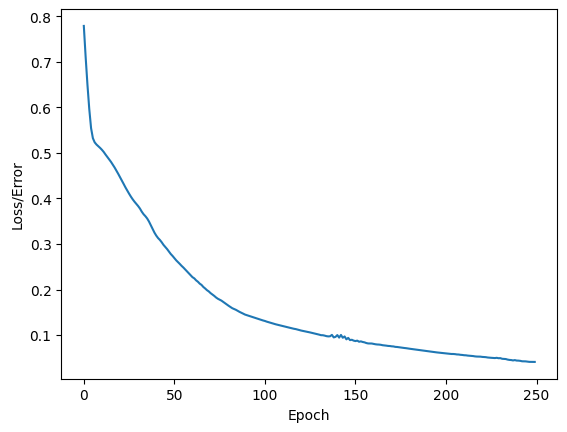

In [23]:
# display on a graph
plt.plot(range(epochs), losses)
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')
model.eval()

### 7. Evaluate the Model Using the Test Dataset


In [24]:
# evaluate model on test dataset
with torch.no_grad():   # turn off back propagation
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)
loss

tensor(0.3093)

In [25]:
correct = 0
y_pred = []

with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        print(f'{i+1}.) {str(y_val)} \t predicted: {y_val.argmax().item()} \t actual: {y_test[i]}')

        # correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1

        y_pred.append(y_val.argmax().item())
    
print(f'Correct: {correct} / {len(X_test)}')

1.) tensor([ 7.1078, -7.8306]) 	 predicted: 0 	 actual: 0
2.) tensor([ 8.9797, -9.8294]) 	 predicted: 0 	 actual: 0
3.) tensor([ 6.3504, -7.1164]) 	 predicted: 0 	 actual: 0
4.) tensor([ 8.5062, -9.4129]) 	 predicted: 0 	 actual: 0
5.) tensor([ 5.1431, -5.6842]) 	 predicted: 0 	 actual: 0
6.) tensor([ 11.1185, -12.4319]) 	 predicted: 0 	 actual: 0
7.) tensor([ 4.5190, -3.9725]) 	 predicted: 0 	 actual: 0
8.) tensor([ 3.4107, -3.7520]) 	 predicted: 0 	 actual: 0
9.) tensor([ 5.6340, -5.2660]) 	 predicted: 0 	 actual: 0
10.) tensor([ 7.8544, -8.5209]) 	 predicted: 0 	 actual: 0
11.) tensor([ 16.6733, -18.2349]) 	 predicted: 0 	 actual: 0
12.) tensor([ 6.8762, -7.5323]) 	 predicted: 0 	 actual: 0
13.) tensor([ 17.0922, -18.8911]) 	 predicted: 0 	 actual: 0
14.) tensor([ 11.8310, -13.2035]) 	 predicted: 0 	 actual: 0
15.) tensor([ 6.1877, -6.8487]) 	 predicted: 0 	 actual: 0
16.) tensor([ 7.8960, -8.0659]) 	 predicted: 0 	 actual: 0
17.) tensor([ 5.9644, -6.5415]) 	 predicted: 0 	 actual: 

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# If doing multi-class (0, 1, 2), you must specify average='weighted' or 'macro'
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Accuracy:  0.9700
Precision: 0.9167
Recall:    0.6875
F1 Score:  0.7857


### 8. Applying the Model to New Data


In [27]:
# new_iris = torch.tensor([6.2, 3.4, 5.4, 2.3])

In [28]:
# with torch.no_grad():
    # print(model(new_iris))

### 9. How to Save and Load the Model


In [29]:
# save NN model
# torch.save(model.state_dict(), 'iris_model.pt')

In [30]:
# load the saved model
# new_model = Model()
# new_model.load_state_dict(torch.load('iris_model.pt'))

In [31]:
# make sure it loaded correctly
# new_model.eval()